### Deep Active Learning - ARL Final Project

By Smayan Khanna

Code help from: https://github.com/ej0cl6/deep-active-learning

In [1]:
# General imports
import os
import json
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import networkx as nx

import torch.nn.functional as F
from torch.utils.data import random_split
import torch
from torch.nn import Linear
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool
import random
import torch_geometric
from torch_geometric.nn import GCNConv
from torch_geometric.nn import GATConv
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import to_networkx

from tqdm import tqdm
from torch_geometric.loader import DataLoader
from torch.utils.data import Subset
from torch_geometric.datasets import TUDataset

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
dataset_path = "data/TUDataset/ENZYMES"
if not os.path.exists(os.path.join(dataset_path, "processed", "data.pt")):
    print("Dataset not found — downloading + processing.")
    dataset = TUDataset(root="data/TUDataset", name="ENZYMES")
else:
    print("Loading cached dataset.")
    dataset = TUDataset(root="data/TUDataset", name="ENZYMES")

Dataset not found — downloading + processing.


Processing...
Done!


In [5]:
global_seed = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # for CuDNN determinism (may slow down training)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(global_seed)

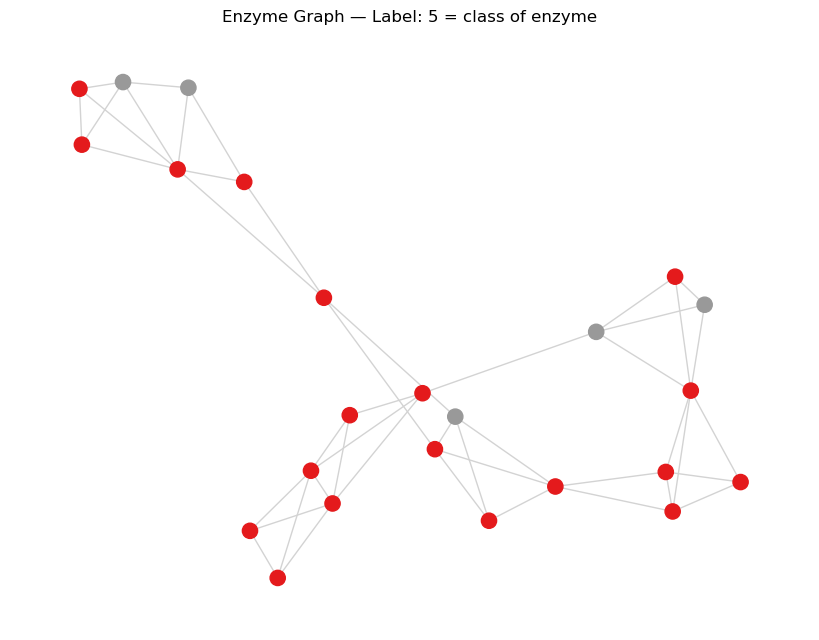

In [8]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
import torch

# Get one of the graphs
graph = dataset[5]  # change the index if you want a different one
G = to_networkx(graph, to_undirected=True)

# Map one-hot vectors to category index (0, 1, 2)
node_colors = torch.argmax(graph.x, dim=1).numpy()

# Plot with a categorical color map (Set1 is vibrant and clean)
plt.figure(figsize=(8, 6))
nx.draw(
    G,
    node_color=node_colors,
    cmap=plt.cm.Set1,  # or try plt.cm.tab10, tab20, etc.
    node_size=120,
    edge_color="lightgray",
    with_labels=False
)

label = graph.y.item()
plt.title(f"Enzyme Graph — Label: {label} = class of enzyme")
plt.axis('off')
plt.show()


In [9]:
perm = torch.randperm(len(dataset)).tolist()
shuffled_dataset = Subset(dataset, perm)


In [19]:
# split dataset into train, test, and unlabeled sets for Deep Active Learning
# 10% test set, 10% initial labeled set, rest unlabeled
total = len(dataset)
n_test = int(0.3* total)
n_init = int(0.15 * total)
n_unlabeled = total - n_test - n_init

#to be used for the active learning loop
labeled_indices = list(range(n_init))
unlabeled_indices = list(range(n_init, n_init+n_unlabeled))
test_indices = list(range(n_init+n_unlabeled, total))


In [20]:
print(n_init)

90


In [23]:
print(n_test)

180


In [24]:
class SplitManager:
    def __init__(self, dataset, init_idxs, test_idxs, batch_size=8, seed = global_seed):
        self.ds = dataset
        self.batch_size = batch_size
        self.seed = seed
        
        # maintain lists
        self.labeled = list(init_idxs)
        self.unlabeled = [i for i in range(len(dataset)) if i not in init_idxs+test_idxs]
        self.test = list(test_idxs)
        

    def get_loader(self, idxs, shuffle=False, batch = True):
        g = torch.Generator().manual_seed(self.seed)
        if batch:
            return DataLoader(Subset(self.ds, idxs), batch_size=self.batch_size, shuffle=shuffle, generator=g if shuffle else None)
        else:
            return DataLoader(Subset(self.ds, idxs), batch_size=1, shuffle=shuffle, generator=g if shuffle else None)

    def labeled_loader(self): 
        return self.get_loader(self.labeled, shuffle=True)

    def unlabeled_loader(self): 
        return self.get_loader(self.unlabeled)

    def test_loader(self):     
        return self.get_loader(self.test, batch=False)

    def add_labels(self, new_idxs):
        self.labeled += new_idxs
        self.unlabeled = [i for i in self.unlabeled if i not in new_idxs]

    def get_dataset_subset(self, idxs):
        return Subset(self.ds, idxs)


In [25]:
split_manager = SplitManager(shuffled_dataset, labeled_indices, test_indices, batch_size=8)

### Models - GCN, GAT, SAGE - Three Canonical GNN Models

In [26]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, num_features = dataset.num_node_features, num_classes = dataset.num_classes, num_layers=2):
        super(GCN, self).__init__()
        torch.manual_seed(global_seed)
        self.convs = nn.ModuleList()

        for n in range(num_layers):
            in_channels = num_features if n == 0 else hidden_channels
            self.convs.append(GCNConv(in_channels, hidden_channels))

        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = conv(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=0.5, training=self.training)
        return self.lin(x)

    def get_graph_embedding(self, x, edge_index, batch):
        for conv in self.convs:
            x = conv(x, edge_index).relu()
        return global_mean_pool(x, batch)

class GAT(torch.nn.Module):
    def __init__(self, hidden_channels, num_features = dataset.num_node_features, num_classes = dataset.num_classes, num_layers=2):
        super(GAT, self).__init__()
        torch.manual_seed(global_seed)
        self.convs = nn.ModuleList()

        for n in range(num_layers):
            in_channels = num_features if n == 0 else hidden_channels
            self.convs.append(GATConv(in_channels, hidden_channels))

        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = conv(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=0.5, training=self.training)
        return self.lin(x)

    def get_graph_embedding(self, x, edge_index, batch):
        for conv in self.convs:
            x = conv(x, edge_index).relu()
        return global_mean_pool(x, batch)

class SAGE(torch.nn.Module):
    def __init__(self, hidden_channels,num_features = dataset.num_node_features, num_classes = dataset.num_classes, num_layers=2):
        super(SAGE, self).__init__()
        torch.manual_seed(global_seed)
        self.convs = nn.ModuleList()

        for n in range(num_layers):
            in_channels = num_features if n == 0 else hidden_channels
            self.convs.append(SAGEConv(in_channels, hidden_channels))

        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = conv(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=0.5, training=self.training)
        return self.lin(x)

    def get_graph_embedding(self, x, edge_index, batch):
        for conv in self.convs:
            x = conv(x, edge_index).relu()
        return global_mean_pool(x, batch)


### Train & Test functions

In [27]:
def train(model, optimizer, labeled_loader, num_epochs=10):
    model.train()
    total_loss = 0

    for epoch in tqdm(range(num_epochs)):
        for data in labeled_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.batch)
            loss = F.cross_entropy(out, data.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * data.num_graphs

    return total_loss / len(labeled_loader.dataset)

def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total_loss = 0

    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            loss = F.cross_entropy(out, data.y)
            total_loss += loss.item() * data.num_graphs
            pred = out.argmax(dim=1)
            correct += (pred == data.y).sum().item()

    return correct / len(test_loader.dataset), total_loss / len(test_loader.dataset)

def compute_mean_embedding(model, loader):
    model.eval()
    graph_embs = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            emb = model.get_graph_embedding(data.x, data.edge_index, data.batch)
            graph_embs.append(emb.cpu())
    
    graph_embs = torch.cat(graph_embs, dim=0)  # [num_graphs, hidden_dim]
    mean_emb = graph_embs.mean(dim=0)
    return mean_emb


In [28]:
model = GCN(hidden_channels=64, num_layers = 2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

train_loss = train(model, optimizer, split_manager.labeled_loader(), num_epochs=20)
acc, loss = evaluate(model, split_manager.test_loader())

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 23.93it/s]


In [29]:
mean_embedding = compute_mean_embedding(model, split_manager.labeled_loader())
mean_embedding.shape

torch.Size([64])

In [30]:
print(f"Test Accuracy: {acc * 100 :.4f}")
print(f"Test Loss: {loss:.4f}")

Test Accuracy: 24.4444
Test Loss: 1.8488


### Query Strategies

In [ ]:
def random_aquisition(unlabeled_set, k=10, model=None):
    """
    Returns the indices of k random samples from the unlabeled set.
    """
    # Randomly select k samples from the unlabeled set
    indices = np.random.choice(len(unlabeled_set), size=k, replace=False)

    return np.ndarray.tolist(indices)

def entropy_sampling(unlabeled_loader, model, k = 10, iter = 3):
    #entropy based sampling
    """
    Returns the indices of k samples from the unlabeled set based on entropy sampling.
    """
    
    model.eval()
    entropy_values = []
    softmax = nn.Softmax(dim=1)

    with torch.no_grad():
        for data in unlabeled_loader:
            data = data.to(device)
            probs = []
            for _ in range(iter):
                logits = model(data.x, data.edge_index, data.batch) 
                probabilities = softmax(logits)
                probs.append(probabilities)
            
            probs = torch.stack(probs, dim=0)
            probs = torch.mean(probs, dim=0)

            entropy = -torch.sum(probs * torch.log(probs + 1e-10), dim=1)
            entropy = entropy.cpu().tolist()
            entropy_values.extend(entropy)        
            
    values, indices = torch.topk(torch.tensor(entropy_values), k)
    return torch.Tensor.tolist(indices)

def embedding_sampling(unlabeled_loader, labelled_mean_embeddings, model, k = 10):
    """
    Returns the indices of k samples from the unlabeled set based on embedding sampling
    """
    embedding_cosine_similarity = []
    model.eval()

    with torch.no_grad():
        cosine_similarity = nn.CosineSimilarity(dim=1, eps=1e-6)
        for data in unlabeled_loader:
            data = data.to(device)
            embeddings = model.get_graph_embedding(data.x, data.edge_index, data.batch)
            repeated_mean = labelled_mean_embeddings.unsqueeze(0).expand(embeddings.size(0), -1)

            distances = cosine_similarity(embeddings, repeated_mean)
            distances = distances.cpu().tolist()
            embedding_cosine_similarity.extend(distances)  
    
    values, indices = torch.topk(torch.tensor(embedding_cosine_similarity), k, largest=True)
    return torch.Tensor.tolist(indices)

def kmeans_sampling(unlabeled_loader, model, k = 10):
    """
    Returns the indices of k samples from the unlabeled set based on k-means sampling. We select points that are closest to the cluster centers.
    """
    from sklearn.cluster import KMeans

    model.eval()
    embeddings = []

    with torch.no_grad():
        for data in unlabeled_loader:
            data = data.to(device)
            emb = model.get_graph_embedding(data.x, data.edge_index, data.batch)
            embeddings.append(emb.cpu())

    embeddings = torch.cat(embeddings, dim=0).numpy()

    #normalize?
    # embeddings = normalize(embeddings) 

    kmeans = KMeans(n_clusters=k, random_state=global_seed)
    kmeans.fit(embeddings)

    # CODE CREDIT - dis code is taken from the GitHub repo linked in the title of the notebook
    cluster_idxs = kmeans.predict(embeddings)
    centers = kmeans.cluster_centers_[cluster_idxs]
    dis = (embeddings - centers)**2
    dis = dis.sum(axis=1)

    selected = []
    for i in range(k):
        candidates = np.where(cluster_idxs == i)[0]
        closest = candidates[dis[candidates].argmin()]
        selected.append(closest)

    return selected

### Active Learning Loop

In [33]:
model = GAT(hidden_channels=16).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=5e-4)

In [34]:
split_manager = SplitManager(shuffled_dataset, labeled_indices, test_indices, batch_size=8)

In [35]:
def run_active_learning_loop(
    model_class,
    acquisition_strategy="random",
    k=10,
    n_rounds=10,
    hidden_channels=64,
    num_epochs=20,
    iter_mc=3,
    num_layers=1,
    lr =0.001,
    reinitialize_model=True,
    split_manager=None,
    dataset=None,

    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
):
    test_acc = []
    test_loss = []

    # Optionally initialize once for warm-start
    if not reinitialize_model:
        model = model_class(hidden_channels, dataset.num_node_features, dataset.num_classes, num_layers=num_layers).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for i in range(n_rounds):
        print(f"Round {i+1}/{n_rounds}")

        if reinitialize_model:
            model = model_class(hidden_channels, dataset.num_node_features, dataset.num_classes).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        labeled_loader = split_manager.labeled_loader()
        unlabeled_loader = split_manager.unlabeled_loader()
        test_loader = split_manager.test_loader()
        print(f"Number of labeled graphs: {len(labeled_loader.dataset)}")
        # Train & evaluate
        train_loss = train(model, optimizer, labeled_loader, num_epochs=num_epochs)
        acc, loss = evaluate(model, test_loader)
        test_acc.append(acc)
        test_loss.append(loss)

        print(f"Test Accuracy: {acc * 100:.2f}% | Test Loss: {loss:.4f}")

        # aquisition step
        if acquisition_strategy == "random":
            local_idxs = random_aquisition(split_manager.get_dataset_subset(split_manager.unlabeled), k=k)

        elif acquisition_strategy == "entropy":
            local_idxs = entropy_sampling(unlabeled_loader, model, k=k, iter=iter_mc)

        elif acquisition_strategy == "embedding":
            mean_embedding = compute_mean_embedding(model, labeled_loader).to(device)
            local_idxs = embedding_sampling(unlabeled_loader, mean_embedding, model, k=k)
        elif acquisition_strategy == "kmeans":
            local_idxs = kmeans_sampling(unlabeled_loader, model, k=k)

        else:
            raise ValueError(f"Unknown acquisition strategy: {acquisition_strategy}")

        global_idxs = [split_manager.unlabeled[i] for i in local_idxs]
        split_manager.add_labels(global_idxs)

    return test_acc, test_loss

def create_split_manager(dataset, seed=global_seed, batch_size=8):
    torch.manual_seed(seed)
    perm = torch.randperm(len(dataset)).tolist()
    n_total = len(dataset)
    n_test = int(0.3 * n_total)
    n_init = int(0.1 * n_total)
    labeled_indices = perm[:n_init]
    test_indices = perm[n_total - n_test:]
    return SplitManager(dataset, labeled_indices, test_indices, batch_size=8)


In [36]:
test_acc, test_loss = run_active_learning_loop(
    model_class=GAT,
    acquisition_strategy="kmeans",
    k=10,
    n_rounds=10,
    hidden_channels=16,
    num_epochs=25,
    reinitialize_model=False,
    split_manager=create_split_manager(dataset),
    dataset=dataset
)


Round 1/10
Number of labeled graphs: 111


100%|██████████| 25/25 [00:01<00:00, 24.16it/s]


Test Accuracy: 65.17% | Test Loss: 0.6757
Round 2/10
Number of labeled graphs: 121


100%|██████████| 25/25 [00:01<00:00, 18.68it/s]


Test Accuracy: 60.96% | Test Loss: 0.6891
Round 3/10
Number of labeled graphs: 131


...

Test Accuracy: 63.36% | Test Loss: 0.6691
Round 9/10
Number of labeled graphs: 191


100%|██████████| 25/25 [00:01<00:00, 14.91it/s]


Test Accuracy: 63.36% | Test Loss: 0.6721
Round 10/10
Number of labeled graphs: 201


100%|██████████| 25/25 [00:01<00:00, 12.78it/s]


Test Accuracy: 63.36% | Test Loss: 0.6708


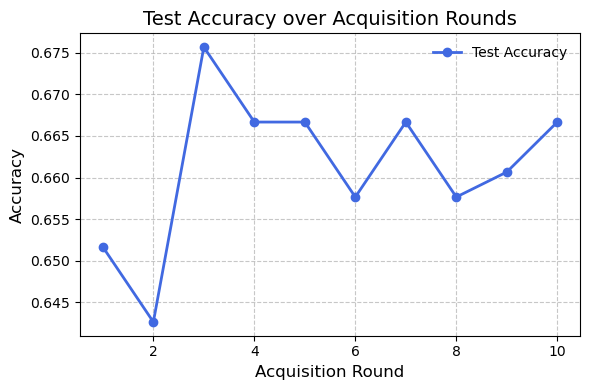

In [27]:

plt.figure(figsize=(6, 4), dpi=100)  # high-res figure
n_rounds = len(test_acc)
plt.plot(range(1, n_rounds+1), test_acc, marker='o', linewidth=2, color='royalblue', label='Test Accuracy')

plt.xlabel('Acquisition Round', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Test Accuracy over Acquisition Rounds', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend(frameon=False)

plt.show()

In [40]:
n_init = int(0.1 * len(dataset))
k = 20
n_rounds = 12

strategies = ["random", "entropy", "embedding", "kmeans"]
results = {}

for strategy in strategies:
    split_manager = create_split_manager(dataset, seed=42)
    acc, _ = run_active_learning_loop(
        model_class=GCN,
        acquisition_strategy=strategy,
        k=k,
        n_rounds=n_rounds,
        hidden_channels=48,
        split_manager=split_manager,
        dataset=dataset,
        reinitialize_model=False
    )
    results[strategy] = acc


Round 1/12
Number of labeled graphs: 111


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 28.30it/s]


Test Accuracy: 64.26% | Test Loss: 0.6778
Round 2/12
Number of labeled graphs: 131


100%|██████████| 20/20 [00:00<00:00, 23.75it/s]


...

Test Accuracy: 63.36% | Test Loss: 0.6450
Round 11/12
Number of labeled graphs: 311


100%|██████████| 20/20 [00:01<00:00, 10.31it/s]


Test Accuracy: 63.66% | Test Loss: 0.6419
Round 12/12
Number of labeled graphs: 331


100%|██████████| 20/20 [00:02<00:00,  8.73it/s]


Test Accuracy: 63.36% | Test Loss: 0.6385


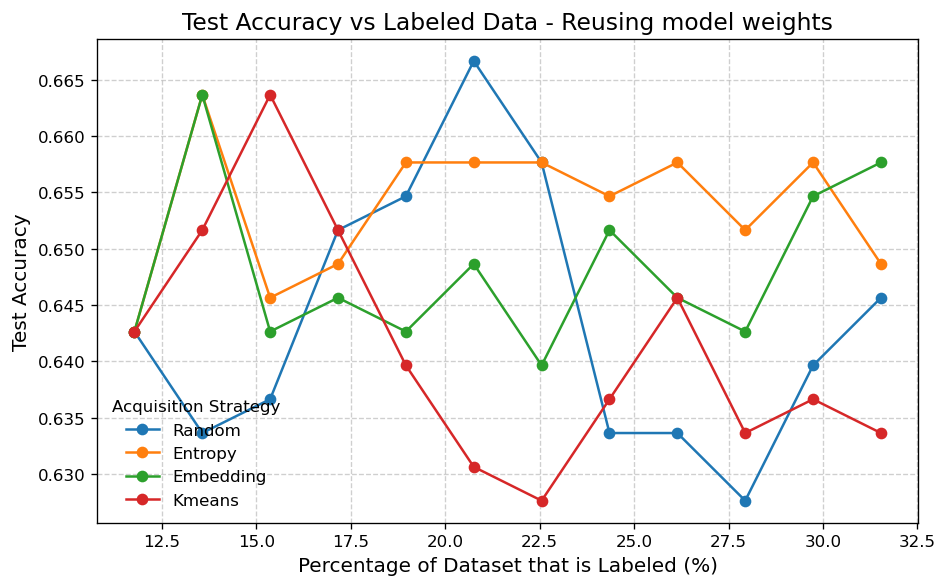

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5), dpi=120)

total_points = [n_init + k * i for i in range(1, n_rounds + 1)]
total_points = np.array(total_points)
percentages = (total_points / len(dataset)) * 100

for strategy, acc_list in results.items():
    plt.plot(percentages, acc_list, marker='o', label=strategy.capitalize())

plt.xlabel("Percentage of Dataset that is Labeled (%)", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.title("Test Accuracy vs Labeled Data - Reusing model weights", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Acquisition Strategy", frameon=False)
plt.tight_layout()
plt.show()


In [2]:
dataset_path = "data/TUDataset/DD"
if not os.path.exists(os.path.join(dataset_path, "processed", "data.pt")):
    print("Dataset not found — downloading + processing.")
    dataset = TUDataset(root="data/TUDataset", name="DD")
else:
    print("Loading cached dataset.")
    dataset = TUDataset(root="data/TUDataset", name="DD")

Dataset not found — downloading + processing.


Processing...
Done!


In [5]:
! cd data/TUDataset && ls

DD  PROTEINS
